In [8]:
!pip3 uninstall -y torch torchvision torchaudio
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.2/819.2 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 90.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 88.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 56.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 60.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 86.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 27.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [5]:
!python3 -c 'import torch; print(torch.version.cuda)'
!nvcc --version

11.7
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Tue_Aug_15_22:02:13_PDT_2023
Cuda compilation tools, release 12.2, V12.2.140
Build cuda_12.2.r12.2/compiler.33191640_0


In [1]:
!pip install pytube
!pip install datasets
!pip install causal-conv1d==1.0.0
!pip install mamba-ssm==1.0.1
!pip install huggingface_hub
!pip install torchinfo
!pip install wandb
!mv kaggle.json /root/.kaggle/kaggle.json

!export LC_ALL="en_US.UTF-8"
!export LD_LIBRARY_PATH="/usr/lib64-nvidia"
!export LIBRARY_PATH="/usr/local/cuda/lib64/stubs"
!ldconfig /usr/lib64-nvidia

mv: cannot stat 'kaggle.json': No such file or directory
/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_0.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc_proxy.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbb.so.12 is not a symbolic link



In [2]:
output_path = "/content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5"


In [ ]:
from pytube import Search
import requests
import os
import csv
import re
def download_thumbnail(url, path):
    """Download a video thumbnail."""
    response = requests.get(url)
    if response.status_code == 200:
        with open(path, 'wb') as file:
            file.write(response.content)
    else:
        print("Failed to download thumbnail.")

def write_to_csv(file_name, views, title, video_id, output_path):
    """Write video information to a CSV file."""
    with open(output_path, mode='a', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow([file_name, views, title, video_id])


def clean_title(title):
    """Remove special characters from the title."""
    new_title =  "".join(x for x in title if x.isalnum() or x in " -_").strip().replace(" ", "_")
    new_title = re.sub(r'[^0-9a-zA-Z_]', '', new_title)
    return new_title

def get_videos_info(search_queries, max_results=100, output_path="thumbnails"):

    """Get information on videos based on a search query."""


    # Ensure the thumbnails directory exists
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    csvfile = os.path.join(output_path,'metadata.csv')
    # Prepare the CSV file with headers if file doesn't exist
    if not os.path.exists(csvfile):
        with open(csvfile, mode='w', newline='', encoding='utf-8') as file:
            writer = csv.writer(file)
            writer.writerow(['file_name', 'views', 'title', 'video_id'])
    for search_query in search_queries:
      s = Search(search_query)
      results = s.results
      index = 0
      try:
        while index < max_results:
            if index >= len(s.results):
                s.get_next_results()
                s.get_next_results()
            video = results[index]
            title = video.title
            views = video.views
            if views < 500:
                print("too few views")
                index += 1
                max_results = max_results + 1
                continue
            video_id = video.video_id
            thumbnail_url = video.thumbnail_url
            safe_title = clean_title(title)

            thumbnail_path = os.path.join(output_path,f'{safe_title}_{video_id}.jpg')
            if os.path.exists(thumbnail_path):
                print(f'Thumbnail already exists: {thumbnail_path}')
                index += 1
                max_results = max_results + 1
                continue
            download_thumbnail(thumbnail_url, thumbnail_path)

            # Write video info to CSV
            write_to_csv(thumbnail_path.split("/")[-1], views, re.sub(r'[^0-9a-zA-Z_]', '', title.replace("_", " ")).replace("_", " "), video_id, csvfile)

            print(f'Title: {title}')
            print(f'Views: {views}')
            print(f'Thumbnail downloaded to: {thumbnail_path}\n')
            print(f'Video ID: {video_id}\n')
            index += 1
      except IndexError:
          pass


# Example usage
search_query = [
    # "Popular music videos",
    "Success stories of entrepreneurs"
    ,"Business plan templates and examples"
    ,"Financial management for businesses"
    ,"Productivity hacks for entrepreneurs"
    ,"Social media marketing for businesses"
    ,"Leadership skills and techniques"
    ,"Business growth strategies"
    ,"Motivational speeches"
    ,"Life hacks and tips"
    ,"Mental health advice and support"
    ,"Personal development and self-improvement"
    ,"Relationship advice and tips"
    ,"Mindfulness and meditation techniques"
    ,"Travel inspiration and experiences"
    ,"Parenting tips and advice"
    ,"Budgeting and financial management tips"
    ,"Healthy lifestyle habits and routines"
    'AI',
    'Tech',
    'Sales',
    "Business",
    "Fun",
    "Video games",
    "Development",
    "Texas",
    "Politics"
    "How to lose weight",
    "Funny cat videos",
    "DIY home improvement projects",
    "Travel vlogs",
    ,"Makeup tutorials"
    ,"Video game walkthroughs"
    ,"Cooking recipes"
    ,"Fitness workouts"
    ,"Movie trailers"
    ,"How to start a business"
    ,"Entrepreneurship tips and advice"
    ,"Small business marketing strategies"
    ]
get_videos_info(search_query, output_path=output_path)


Title: EXTRA GLAM Makeup Tutorial
Views: 10615935
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/EXTRA_GLAM_Makeup_Tutorial_nf8ySuesAPg.jpg

Video ID: nf8ySuesAPg

Title: MY GO-TO MAKEUP, SIMPLE, CLEAN LOOK!
Views: 343435
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/MY_GOTO_MAKEUP_SIMPLE_CLEAN_LOOK_i2nmzHs5tvU.jpg

Video ID: i2nmzHs5tvU

Title: COPYING MY 15 YEAR OLD SISTER'S MAKEUP ROUTINE!!!
Views: 2797298
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/COPYING_MY_15_YEAR_OLD_SISTERS_MAKEUP_ROUTINE_U8FXuGd1gNw.jpg

Video ID: U8FXuGd1gNw

Title: Step by Step Beginner Makeup Tutorial
Views: 1142129
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Step_by_Step_Beginner_Makeup_Tutorial_U29xgUOXzPY.jpg

Video ID: U29xgUOXzPY

Title: Updated makeup tutorial !
Views: 441061
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5

Title: ‘clean girl’ makeup & hair tutorial
Views: 3242392
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/clean_girl_makeup__hair_tutorial_y46hvE9JAXo.jpg

Video ID: y46hvE9JAXo

Title: The power of nose contour 😱 #nosecontouring #nosecontour #makeupchallenge #makeup #tutorial
Views: 7851416
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/The_power_of_nose_contour__nosecontouring_nosecontour_makeupchallenge_makeup_tutorial_G-_NPRHxX50.jpg

Video ID: G-_NPRHxX50

Title: back to school makeup tutorial *EASY*
Views: 167472
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/back_to_school_makeup_tutorial_EASY_ec4HgyRNYHU.jpg

Video ID: ec4HgyRNYHU

Title: FULL COVERAGE Makeup Tutorial
Views: 3729878
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/FULL_COVERAGE_Makeup_Tutorial_IIg1MlvkiuQ.jpg

Video ID: IIg1MlvkiuQ

Title: JOJO'S BIZARRE MAKEUP TUTORIAL
Views:

Title: Makeup Video 🖤 #makeuptutorial #nyadollie #mua #reels #darkskin #beauty #makeup #fentybeauty #grwm
Views: 48954497
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Makeup_Video__makeuptutorial_nyadollie_mua_reels_darkskin_beauty_makeup_fentybeauty_grwm_qJvWOMSUK9U.jpg

Video ID: qJvWOMSUK9U

Title: ASMR mannequin 🎭makeup tutorials, step by step, before and after looks. Smoky eyes nude lips.
Views: 73654040
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/ASMR_mannequin_makeup_tutorials_step_by_step_before_and_after_looks_Smoky_eyes_nude_lips_LJvJXGhcm38.jpg

Video ID: LJvJXGhcm38

Title: the ultimate soft glam makeup tutorial! perfect for bridal, prom & night out makeup 💍✨
Views: 311318
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/the_ultimate_soft_glam_makeup_tutorial_perfect_for_bridal_prom__night_out_makeup_ittU1pNuYuM.jpg

Video ID: ittU1pNuYuM

Title: Simple Glitter Eye Ma

Thumbnail already exists: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Sweet_vs_Baddie__which_do_you_prefer_makeup_shorts_makeuptutorial_rrBV24Ook84.jpg
Thumbnail already exists: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Who_should_Kassie_be_next__Harley_Quinn_Makeup_Transformation_ZRUaNKI9ysI.jpg
Thumbnail already exists: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/GIRLY_GLAM_MAKEUP_TUTORIAL_Kc9Cl34sP3g.jpg
Title: Best Makeup Transformations 2024 | New Makeup Tutorials Compilation
Views: 876
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Best_Makeup_Transformations_2024__New_Makeup_Tutorials_Compilation_pBERmd2pjjc.jpg

Video ID: pBERmd2pjjc

Thumbnail already exists: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Me_giving_a_makeup_tutorial_in_1998_dq1CgTg_b-o.jpg
Thumbnail already exists: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Kylie_Jenners_New_Classic_Beauty_Routine__Beauty_Secret

Title: SKULL AND BONES PS5 Walkthrough Gameplay Part 1 - INTRO (FULL GAME)
Views: 766929
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/SKULL_AND_BONES_PS5_Walkthrough_Gameplay_Part_1__INTRO_FULL_GAME__t--dIfd-yI.jpg

Video ID: _t--dIfd-yI

Title: FORSPOKEN Gameplay Walkthrough Part 1 FULL GAME [4K 60FPS PS5] -  No Commentary
Views: 575317
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/FORSPOKEN_Gameplay_Walkthrough_Part_1_FULL_GAME_4K_60FPS_PS5___No_Commentary_HETPBy65tyw.jpg

Video ID: HETPBy65tyw

Title: Super Mario Odyssey - 100% Longplay Full Game Walkthrough No Commentary Gameplay Playthrough
Views: 8541263
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Super_Mario_Odyssey__100_Longplay_Full_Game_Walkthrough_No_Commentary_Gameplay_Playthrough_vDwQpTFW2us.jpg

Video ID: vDwQpTFW2us

Title: DEAD SPACE REMAKE Gameplay Walkthrough Part 1 FULL GAME [4K 60FPS] - No Commentary
Views:

...

Title: How To Market Your Business On Social Media
Views: 1652098
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/How_To_Market_Your_Business_On_Social_Media_RmwI_QqcPQc.jpg

Video ID: RmwI_QqcPQc

Title: 15 Psychological Marketing Triggers to MAKE PEOPLE BUY From YOU!
Views: 504239
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/15_Psychological_Marketing_Triggers_to_MAKE_PEOPLE_BUY_From_YOU_hYZG8qnS2T4.jpg

Video ID: hYZG8qnS2T4

Title: Marketing Strategies For Small Business - 5 Growth Hacks (Ep. #32)
Views: 122157
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Marketing_Strategies_For_Small_Business__5_Growth_Hacks_Ep_32_hfReofDo2TI.jpg

Video ID: hfReofDo2TI

Title: Beginner Friendly Marketing & Social Media Strategies For Your Business in 2023 | Troyia Monay
Views: 11839
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Beginner_Friendly_Marketing

Title: Low Cost Marketing Strategies You Must Know in 2022 | New Age Marketing Strategies to Grow 15x
Views: 62828
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Low_Cost_Marketing_Strategies_You_Must_Know_in_2022__New_Age_Marketing_Strategies_to_Grow_15x__BEXkIMUm_U.jpg

Video ID: _BEXkIMUm_U

Thumbnail already exists: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Best_Advice_to_Small_Business_Owners_0PbjZ01ObLA.jpg
Title: 22k in 1 day | My Business Launch Strategy: Tips To Successfully Launch Your Business
Views: 66515
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/22k_in_1_day__My_Business_Launch_Strategy_Tips_To_Successfully_Launch_Your_Business_qbly3jdCMlY.jpg

Video ID: qbly3jdCMlY

Title: 3 Social Media Marketing Strategies GUARANTEED To Grow Your Business
Views: 219831
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/3_Social_Media_Marketing_Strategies_GUARANTEED_To

Title: How Starbucks Became a $100B Success Story | Howard Schultz | From Poor Boy To Billionaire
Views: 1006270
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/How_Starbucks_Became_a_100B_Success_Story__Howard_Schultz__From_Poor_Boy_To_Billionaire_i9UYbJ2xMTI.jpg

Video ID: i9UYbJ2xMTI

Title: 10 Entrepreneur Success Stories That Will Inspire You
Views: 16331
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/10_Entrepreneur_Success_Stories_That_Will_Inspire_You_Od7gQAc-sBI.jpg

Video ID: Od7gQAc-sBI

Thumbnail already exists: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/I_Got_Rich_When_I_Understood_This__Jeff_Bezos_7TWKKww-F30.jpg
Thumbnail already exists: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/50_Entrepreneurs_share_priceless_advice_QoqohmccTSc.jpg
Thumbnail already exists: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Jeff_Bezos_Advice_For_young_Entrepreneurs_30pxmKvkzFM.jpg
Ti

Title: Young Entrepreneurs Share Their Success Story | Motivational Video for Kids
Views: 48402
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/Young_Entrepreneurs_Share_Their_Success_Story__Motivational_Video_for_Kids_XQ4RESzO2wI.jpg

Video ID: XQ4RESzO2wI

Title: DADA Success Stories: Roseline Wamaitha Mwai, Entrepreneur
Views: 6963
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/DADA_Success_Stories_Roseline_Wamaitha_Mwai_Entrepreneur_LrDMFiO91Hk.jpg

Video ID: LrDMFiO91Hk

Title: 10 Most Successful Young Entrepreneurs 2020
Views: 154859
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/10_Most_Successful_Young_Entrepreneurs_2020_MGoiy74h1CM.jpg

Video ID: MGoiy74h1CM

Title: How A Housewife Became A Successful Entrepreneur | Harini Sivakumar | Josh Talks
Views: 578351
Thumbnail downloaded to: /content/drive/MyDrive/HorrorGPT/Thumbnails/thumbnailsv5/How_A_Housewife_Became_A_Successful

KeyboardInterrupt: 

In [ ]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To login, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Token: 
Add token as git credential? (Y/n) n
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


In [ ]:
import torch
from datasets import load_dataset
tb_dataset = load_dataset("imagefolder", data_dir=output_path, split='train')
tb_dataset.push_to_hub("GeneralRincewind/ThumbnailDataset")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/1294 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/13 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/GeneralRincewind/ThumbnailDataset/commit/c34fefe75827f5a0759245fd0a35c4254cdd6db7', commit_message='Upload dataset', commit_description='', oid='c34fefe75827f5a0759245fd0a35c4254cdd6db7', pr_url=None, pr_revision=None, pr_num=None)

In [3]:
import torchvision.transforms.functional as TVF
import torchvision
import torch
from datasets import load_dataset



tb_dataset = load_dataset("GeneralRincewind/ThumbnailDataset", split='train', streaming=True)
# shuffled_dataset = dataset.shuffle(seed=42, buffer_size=10_000)
# tb_dataset = load_dataset("imagefolder", data_dir=output_path, split='train', streaming=True)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
resize_transform = torchvision.transforms.Resize((720, 1296))
to_tensor = torchvision.transforms.ToTensor()
def apply_transform(d):
  img_tensor = to_tensor(d['image'])
  img_tensor = resize_transform(img_tensor)

  return {"normalized_image":img_tensor}

mapped_dataset = tb_dataset.map(apply_transform, remove_columns=['image'])

In [4]:
import torchvision.transforms.functional as TVF
import torchvision
import torch
from datasets import load_dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from mamba_ssm import Mamba
from einops import rearrange, repeat
from einops.layers.torch import Rearrange
from tqdm import tqdm




# Hyperparameters
patch_size=72
dim=512
heads=8
dt_rank=32
n_layers=16
d_state=256
dropout=0.2

device = "cuda" if torch.cuda.is_available() else "cpu"

def pair(t):
    return t if isinstance(t, tuple) else (t, t)
class FeedForward(nn.Module):
  def __init__(self, n_embed, dropout) -> None:
    super().__init__()
    self.ffn = nn.Sequential(
      nn.Linear(n_embed, 4*n_embed),
      nn.ReLU(),
      nn.Linear(4*n_embed, n_embed),
      nn.Dropout(dropout),
    )
  def forward(self, x):
    return self.ffn(x)
class Block(nn.Module):
  def __init__(self, n_embed, dt_rank, dropout) -> None:
    super().__init__( )
    self.sa_head = Mamba(
      # This module uses roughly 3 * expand * d_model^2 parameters
      d_model=n_embed, # Model dimension d_model
      d_state=16,  # SSM state expansion factor
      d_conv=4,    # Local convolution width
      expand=1,    # Block expansion factor
  ).to("cuda")
    self.ffn = FeedForward(n_embed, dropout=dropout)
    self.ln1 = nn.LayerNorm(n_embed)
    self.ln2 = nn.LayerNorm(n_embed)


  def forward(self, x):
    x = x + self.sa_head(self.ln1(x))
    x = x + self.ffn(self.ln2(x))

    return x
class VMamba(nn.Module):
    def __init__(self, *, image_size, patch_size=32, dim=512, heads=8, d_state=256, dt_rank=32,n_layers=8, pool = 'mean', channels = 3,  dropout = 0., emb_dropout = 0.):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = channels * patch_height * patch_width
        assert pool in {'cls', 'mean'}, 'pool type must be either cls (cls token) or mean (mean pooling)'

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = patch_height, p2 = patch_width),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)
        self.blocks = nn.Sequential(*[Block(dim,dt_rank=dt_rank, dropout=dropout) for _ in range(n_layers)])

        self.pool = pool
        self.to_latent = nn.Identity()
        self.output = nn.Sequential(*[
            nn.Linear(dim, dim//4),
            nn.ReLU(),
            nn.Linear(dim//4, dim//8),
            nn.ReLU(),
            nn.Linear(dim//8, 1),
            nn.RReLU(),
            nn.Linear(1, 1),
        ])


    def forward(self, img):
        x = self.to_patch_embedding(img)
        b, n, _ = x.shape

        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b = b)
        x = torch.cat((cls_tokens, x), dim=1)
        # x += self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)

        x = self.blocks(x)
        x = x.mean(dim = 1)

        x = self.to_latent(x)
        x = self.output(x)
        return x



ImportError: /usr/local/lib/python3.10/dist-packages/causal_conv1d_cuda.cpython-310-x86_64-linux-gnu.so: undefined symbol: _ZN3c104cuda20CUDACachingAllocator9allocatorE

In [ ]:
# from torchvision.models import resnet50
# class ResnetModified(nn.Module):
#   def __init__(self) -> None:
#     super().__init__( )
#     self.resnet = resnet50(pretrained=True)
#     self.output = nn.Sequential(*[
#             nn.Linear(1000, 1000),
#             nn.Linear(1000, 1),
#             nn.ReLU()
#         ])
#   def forward(self, x):
#     x = self.resnet(x)
#     x = self.output(x)
#     return x

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torchvision
# from tqdm.notebook import tqdm
# import math
# import torchinfo


# epochs = 1000
# lr = 1e-5
# batch_size=4

# train_dataloader = torch.utils.data.DataLoader(mapped_dataset.with_format('torch'), batch_size=batch_size)
# maxview = 0
# views = []
# for batch in tqdm(train_dataloader, total=1296//batch_size):
#   for view in batch['views']:
#     # print(view)
#     views.append(float(view))
#     maxview = max(maxview, view)
# views = torch.log(torch.tensor(views))
# std = views.std()
# mean = views.mean()
# print(std, mean, maxview)

  0%|          | 0/324 [00:00<?, ?it/s]

tensor(2.3871) tensor(13.7329) tensor(1696780273)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from tqdm.notebook import tqdm
import math
import torchinfo

epochs = 1000
lr = 1e-5
batch_size=8

model = VMamba( image_size=(720, 1296),
                patch_size=patch_size,
                dim=dim,
                heads=heads,
                dt_rank=dt_rank,
                n_layers=n_layers,
                d_state=d_state,
                dropout=dropout
               ).to(device)
optimizer = torch.optim.AdamW(model.parameters(),lr=lr)
train_dataloader = torch.utils.data.DataLoader(mapped_dataset.with_format('torch'), batch_size=batch_size)
loss_func = nn.MSELoss()
ind = 0
losses = []
print(torchinfo.summary(model))
for d in tqdm(range(epochs)):
  for batch in tqdm(train_dataloader, total=1296//batch_size):
    # Making sure the images are in the right format
    img_resized = batch['normalized_image'].reshape(-1,3,720, 1296 ).to(device).to(torch.float32)
    # Making sure the views are in the right format
    views = torch.tensor(batch['views']).to(device).to(torch.float32).reshape(-1,1)/torch.log(torch.tensor(10.0))
    # Taking the log of the view
    views = torch.log(views)
    output_view = model(img_resized)

    loss = loss_func(output_view, views)
    optimizer.zero_grad()
    loss.backward()

    torch.nn.utils.clip_grad.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if ind % (100//batch_size) == 0:
      print(f'lastloss', loss.item(),math.log(loss.item()))
      print(output_view, views)
    losses.append(loss.item())
    ind = ind + 1

Layer (type:depth-idx)                   Param #
VMamba                                   93,184
├─Sequential: 1-1                        --
│    └─Rearrange: 2-1                    --
│    └─LayerNorm: 2-2                    31,104
│    └─Linear: 2-3                       7,963,136
│    └─LayerNorm: 2-4                    1,024
├─Dropout: 1-2                           --
├─Sequential: 1-3                        --
│    └─Block: 2-5                        --
│    │    └─Mamba: 3-1                   847,360
│    │    └─FeedForward: 3-2             2,099,712
│    │    └─LayerNorm: 3-3               1,024
│    │    └─LayerNorm: 3-4               1,024
│    └─Block: 2-6                        --
│    │    └─Mamba: 3-5                   847,360
│    │    └─FeedForward: 3-6             2,099,712
│    │    └─LayerNorm: 3-7               1,024
│    │    └─LayerNorm: 3-8               1,024
│    └─Block: 2-7                        --
│    │    └─Mamba: 3-9                   847,360
│    │    └─

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/162 [00:00<?, ?it/s]

<ipython-input-24-5da0471ca1e6>:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  views = torch.tensor(batch['views']).to(device).to(torch.float32).reshape(-1,1)/torch.log(torch.tensor(10.0))


lastloss 150.91856384277344 5.016740379034224
tensor([[0.2660],
        [0.2835],
        [0.2385],
        [0.2337],
        [0.2978],
        [0.2715],
        [0.2652],
        [0.2866]], device='cuda:0', grad_fn=<AddmmBackward0>) tensor([[15.0879],
        [14.1654],
        [13.2554],
        [10.3335],
        [13.4378],
        [12.5960],
        [11.0515],
        [ 9.3758]], device='cuda:0')
lastloss 140.73834228515625 4.946902437906837
tensor([[0.9457],
        [0.8278],
        [1.6800],
        [1.2846],
        [1.2802],
        [1.8638],
        [1.0162],
        [1.6137]], device='cuda:0', grad_fn=<AddmmBackward0>) tensor([[11.0579],
        [13.1846],
        [13.4246],
        [14.4363],
        [14.8749],
        [12.9917],
        [11.6627],
        [13.3637]], device='cuda:0')
lastloss 104.06746673583984 4.645039407428254
tensor([[2.8152],
        [1.8879],
        [2.3201],
        [2.7442],
        [2.3681],
        [2.0413],
        [2.7331],
        [2.9656]], d

...

  0%|          | 0/162 [00:00<?, ?it/s]

lastloss 3.6498332023620605 1.2946814685672183
tensor([[13.4313],
        [13.0784],
        [13.4219],
        [13.5766],
        [13.2257],
        [13.3693],
        [12.8936],
        [13.5514]], device='cuda:0', grad_fn=<AddmmBackward0>) tensor([[13.4905],
        [10.0945],
        [11.9118],
        [14.4821],
        [16.3072],
        [15.4310],
        [11.2910],
        [14.4876]], device='cuda:0')
lastloss 5.918482780456543 1.7780801289637236
tensor([[13.1559],
        [12.9220],
        [12.4338],
        [12.7904],
        [12.8681],
        [12.6233],
        [13.1318],
        [12.9909]], device='cuda:0', grad_fn=<AddmmBackward0>) tensor([[14.1495],
        [12.2009],
        [13.5524],
        [ 8.1052],
        [12.1340],
        [ 8.7068],
        [11.5121],
        [15.0245]], device='cuda:0')
lastloss 7.8872785568237305 2.065251152268617
tensor([[12.1025],
        [12.3876],
        [12.0978],
        [12.0782],
        [12.3507],
        [12.3994],
        [12.831

  0%|          | 0/162 [00:00<?, ?it/s]

lastloss 3.9378020763397217 1.3706227190096558
tensor([[12.9097],
        [13.0453],
        [13.0773],
        [12.9431],
        [12.5939],
        [12.9531],
        [12.9106],
        [13.1660]], device='cuda:0', grad_fn=<AddmmBackward0>) tensor([[15.0879],
        [14.1654],
        [13.2554],
        [10.3335],
        [13.4378],
        [12.5960],
        [11.0515],
        [ 9.3758]], device='cuda:0')
lastloss 1.3420400619506836 0.2941908905261833
tensor([[13.1374],
        [13.0587],
        [13.7655],
        [13.2913],
        [13.3659],
        [13.9891],
        [12.9620],
        [13.4569]], device='cuda:0', grad_fn=<AddmmBackward0>) tensor([[11.0579],
        [13.1846],
        [13.4246],
        [14.4363],
        [14.8749],
        [12.9917],
        [11.6627],
        [13.3637]], device='cuda:0')
lastloss 4.101715087890625 1.4114052003609676
tensor([[13.1845],
        [11.9732],
        [12.0260],
        [12.6091],
        [12.7467],
        [12.1058],
        [12.72

KeyboardInterrupt: 

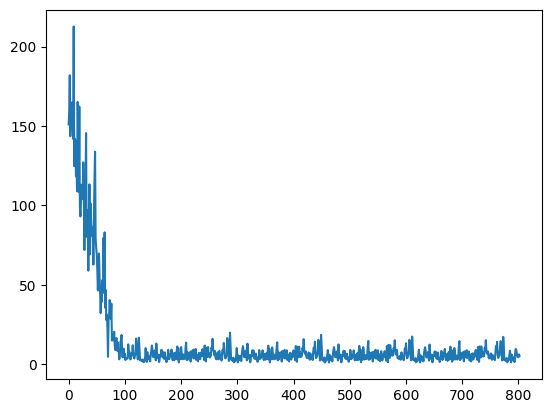

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
loglosses = (torch.tensor(losses)).numpy()
plt.plot(loglosses)
plt.savefig("losses.png")

In [ ]:
from pytube import YouTube
from IPython.display import Image, display, Markdown
from torchvision.io import read_image
import PIL
import requests
def download_thumbnail(url, path):
    """Download a video thumbnail."""
    response = requests.get(url)
    if response.status_code == 200:
        with open(path, 'wb') as file:
            file.write(response.content)
    else:
        print("Failed to download thumbnail.")
example_videos = [
    "https://www.youtube.com/watch?v=xPA0LFzUDiE",
    "https://www.youtube.com/watch?v=TU1gMloI0kc",
    "https://www.youtube.com/watch?v=FTs35x-xUg4",
    # "https://www.youtube.com/watch?v=Pdwm1SoJlQw",
    "https://www.youtube.com/watch?v=LdlLUogNYMw",
    "https://www.youtube.com/watch?v=b0HfmY64eSE"
]
for ev in example_videos:
  video = YouTube(ev)
  video_views = video.views
  download_thumbnail(video.thumbnail_url, "thumbnail.png")
  img_tensor = PIL.Image.open("thumbnail.png")
  img_tensor = to_tensor(img_tensor)
  img_tensor = resize_transform(img_tensor).unsqueeze(0)
  # print(img_tensor.shape)
  log_view = model(img_tensor.to(device))
  # print(log_view)
  predicted_views = math.exp(log_view.item())
  # print(f"Actual Views:{video.views}. Predicted views:{predicted_views}")
  text_to_display = f"<h2><b>Actual Views:</b> {video_views}. <b>Predicted views:</b> {predicted_views}</h2>"
  title_to_display = f"<h2><b>{video.title}</b></h2>"

  display(Markdown(title_to_display))
  display(Markdown(text_to_display))
  display(Image(url=video.thumbnail_url))



/usr/local/lib/python3.10/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


<h2><b>Google has the best AI now, but there's a problem...</b></h2>

<h2><b>Actual Views:</b> 912199. <b>Predicted views:</b> 449701.0683220229</h2>

<h2><b>OpenAI Sora All Example Videos.</b></h2>

<h2><b>Actual Views:</b> 210873. <b>Predicted views:</b> 257252.96266029778</h2>

...

<h2><b>Actual Views:</b> 110065. <b>Predicted views:</b> 257282.64997388292</h2>

<h2><b>I bought the CHEAPEST Tech in India!</b></h2>

<h2><b>Actual Views:</b> 492119. <b>Predicted views:</b> 302266.7802529404</h2>

<h2><b>I bought the most FUTURISTIC Tech in the World</b></h2>

<h2><b>Actual Views:</b> 13328514. <b>Predicted views:</b> 614439.3234207497</h2>